# **1st problem : compute the probability of an observation given the model**

In the first place, I will try to a simple model that recognizes yes and no.

we will have two models, each one has three states.
Each state is characterized by the mean and the density of the observations bi(k) is a gaussian.

we will fix yes as the sequence of states with the following means :  **2, 4, 3**
and no as the sequence of states with the following means :  **3, 2, 1**
the transition matrix will keep them as simple as possible, **50%** chance to stay in the same state or to go to the next.


# **2nd problem : search the best hidden state sequence given the model and the observation sequence**

 Now that we have an algo that computes the probability of an observation sequence given the model,

 we need to find the best sequence of hidden states that explains the observation sequence

 we can use the same Viterbi algorithm, in addition to the probability we shoud keep track of the best previous state for each time slot


In [59]:
import math

def gaussian(x, mean, variance = 1):
  """ compute the value of the gaussian for a given x
  """
  if variance == 0 :
      numerator = math.exp(-0.5 * ((x - mean) ** 2) / 1e-8)
  else :
      numerator = math.exp(-0.5 * ((x - mean) ** 2) / variance)

  if variance == 0 :
      denominator = math.sqrt(2 * 3.14159 * 1e-8)
  else :
      denominator = math.sqrt(2 * 3.14159 * variance)

  return numerator / denominator


In [60]:


def viterbi(observations, A, B, pi , variance = 1):
    """ Will compute the probability of an observation sequence given the model (A, B, pi) using the Viterbi algorithm
    I added also the tracking of the best previous state for each time slot """

    # initialization
    # delta 1 (j) = pi(j) * bi(o1)
    # les autres sont a 0, car c'est un model left-right.
    psi = [[0] * len(A) for _ in range(len(observations))]

    delta = [0] * len(A)
    delta[0] = pi[0] * gaussian(observations[0], B[0], variance[0])  # probability of the initial state
    #print("delta at time 0 : ", delta)


    # recursion
    for t in range(1, len(observations)):
        # on calcule le meiller score pour chaque etat a l'instant t
        # delta t(j) = max (delta t-1(i) * aij) * bi(ot)
        new_delta = [0] * len(A)
        # dor each state
        for j in range(len(A)):
            best_previous = list()

            # delta t-1(i) * aij
            for i in range(len(A)):
                best_previous.append(delta[i] * A[i][j])

            # max ( delta t-1(i) * aij ) * bi(ot)
            best_previous_score = max(best_previous)
            new_delta[j] = best_previous_score * gaussian(observations[t], B[j], variance[j])
            psi[t][j] = best_previous.index(best_previous_score)

        delta = new_delta
        #print("delta at time ", t, " : ", delta)

    path = [0] * len(observations)
    path[-1] = len(A) - 1
    for t in range(len(observations) - 1, 0, -1):
        path[t - 1] = psi[t][path[t]]

    return delta[-1]*0.5, path   # la probabilite de la fin



In [61]:


# example

# start probabilities
pi = [1, 0, 0]

# exit probability
exit = 0.5

# transition matrices
YesA = [
    [0.5, 0.5, 0],
    [0, 0.5, 0.5],
    [0, 0, 0.5]
]
NoA = [
    [0.5, 0.5, 0],
    [0, 0.5, 0.5],
    [0, 0, 0.5]
]

# State means and variances
YesStates = [2, 4, 3]

NoStates = [3, 2, 1]

variance = [1, 1, 1]

# observation sequence
observation = [1, 3, 3, 4]


# compute the probability of the observation sequence given the model
print("P of the observation O given the Yes model: ", viterbi(observation, YesA, YesStates, pi, variance)[0])
print("P of the observation O given the No model: ", viterbi(observation, NoA, NoStates, pi, variance)[0])

if viterbi(observation, YesA, YesStates, pi, variance)[0] > viterbi(observation, NoA, NoStates, pi, variance)[0]:
    print("The sequence given is a Yes")
else:
    print("The sequence given is a No")


P of the observation O given the Yes model:  0.00035324765819680175
P of the observation O given the No model:  1.4436424402230064e-06
The sequence given is a Yes


# **3rd problem : learn the model parameters given the observation sequence**

## Mathematical computing

In [62]:
def forward(observations, A, B, pi, variance = 1):
    """it's almost like the viterbi algorithm, but we will sum the probabilities instead of taking the max
    alpha t(i) =  sum (alpha t-1(j) * aij) * bi(ot)"""

    # initialization
    # delta 1 (j) = pi(j) * bi(o1)
    # les autres sont a 0, car c'est un model left-right.

    alphas = list()
    delta = [0] * len(A)
    delta[0] = pi[0] * gaussian(observations[0], B[0], variance[0])  # probability of the initial state

    alphas.append(delta)

    # recursion
    for t in range(1, len(observations)):
        # on calcule le meiller score pour chaque etat a l'instant t
        # delta t(j) = max (delta t-1(i) * aij) * bi(ot)
        new_delta = [0] * len(A)

        # dor each state
        for j in range(len(A)):
            best_previous = list()

            # delta t-1(i) * aij
            for i in range(len(A)):
                best_previous.append(delta[i] * A[i][j])

            # sum ( delta t-1(i) * aij ) * bi(ot)
            best_previous_score = sum(best_previous)
            new_delta[j] = best_previous_score * gaussian(observations[t], B[j], variance[j])

        delta = new_delta
        alphas.append(delta)

    return alphas


In [63]:


def backward(observations, A, B, variance=1):
    # initialization
    betas = list()

    beta = [0] * len(A)   # betaT(i) = 1 for all i
    beta[-1] = 0.5

    betas.append(beta)

    # inverse recursion
    for t in range(len(observations) - 2, -1, -1):
        new_beta = [0] * len(A)

        for i in range(len(A)):
            best_previous = []

            for j in range(len(A)):
                score = A[i][j] * gaussian(observations[t + 1], B[j], variance[j]) * beta[j]
                best_previous.append(score)

            new_beta[i] = sum(best_previous)

        beta = new_beta
        betas.append(beta)

    return betas[::-1]


In [64]:

def gamma(observations, A, B, pi, variance=1):
    """ gamma t(i) = alpha t(i) * beta t(i) / P(O|lambda) """
    alphas = forward(observations, A, B, pi, variance)
    betas = backward(observations, A, B, variance)

    prob = alphas[-1][-1] * 0.5

    gammas = list()

    for t in range(len(observations)):
        tmp = list()
        for i in range(len(A)):
            if prob == 0 :
                tmp.append(1e-8)
            else :
                tmp.append(alphas[t][i] * betas[t][i] / prob)
        gammas.append(tmp)

    return gammas


In [65]:

def ksi(observations, A, B, pi, variance=1):
    """ ksi t(i,j) = alpha t(i) * aij * bj(ot+1) * beta t+1(j) / P(O|lambda) """
    alphas = forward(observations, A, B, pi, variance)
    betas = backward(observations, A, B, variance)

    prob = alphas[-1][-1] * 0.5

    ksi = list()
    for t in range(len(observations) - 1):
        matrix = list()
        for i in range(len(A)):
            lig = list()
            for j in range(len(A)):
                bj = gaussian(observations[t+1], B[j], variance[j])
                if prob == 0 :
                    lig.append(1e-8)
                else :
                    lig.append(alphas[t][i] * A[i][j] * bj * betas[t + 1][j]/prob)
            matrix.append(lig)
        ksi.append(matrix)

    return ksi


## Application

In [66]:


def reestimate(observations : list[list], A : list[list], B : list, pi : list, variance : list) -> tuple:
    """ this function will help us to reestimate the parameters of the HMM """

    newA = list()
    for i in range(len(A)):
        row = list()
        for j in range(len(A)):
            # we want to keep it a left-right model
            if A[i][j] == 0 :
                row.append(0)
                continue

            numTranij = 0
            numTrani = 0

            for observation in observations :
                gammas = gamma(observation, A, B, pi, variance)
                xi = ksi(observation, A, B, pi, variance)
                for t in range(len(observation) - 1):
                    numTranij += xi[t][i][j]
                for t in range(len(observation) - 1):
                    numTrani += gammas[t][i]

            if numTrani == 0 :
                row.append(1e-8)
            else :
                row.append(numTranij / numTrani)
        newA.append(row)

    newB = list()
    for j in range(len(A)):
        expeStaj = 0
        expecNum = 0

        for observation in observations :
            gammas = gamma(observation, A, B, pi, variance)
            for t in range(len(observation)):
                expeStaj += gammas[t][j]
            for t in range(len(observation)):
                expecNum += gammas[t][j] * observation[t]

        if expeStaj == 0 :
            newB.append(1e-8)
        else :
            newB.append(expecNum / expeStaj)


    newVar = list()
    for j in range(len(A)):
        expeStaj = 0
        nominator = 0

        for observation in observations :
            gammas = gamma(observation, A, B, pi, variance)
            for t in range(len(observation)):
                expeStaj += gammas[t][j]
            for t in range(len(observation)):
                nominator += gammas[t][j] * (observation[t] - newB[j]) ** 2

        if expeStaj == 0 :
            newVar.append(1e-8)
        else :
            newVar.append(nominator / expeStaj)

    return newA, newB, newVar


def learning(observations, A, B, pi, variance):
    """ learning loop of the model """
    oldA, oldB, oldVariance = A, B, variance
    for i in range(15):
        newA, newB, newVariance = reestimate(observations, oldA, oldB, pi, oldVariance)
        oldA, oldB, oldVariance = newA, newB, newVariance

    return oldA, oldB, oldVariance



In [67]:
def load_data(path) -> list[list] :
    content = list()
    file = open(path, 'r')
    line = file.readline()
    while line :
        observ = line.split()
        observ = list( map(float, observ) )
        content.append(observ)
        line = file.readline()
    file.close()
    return content

In [68]:
test =  [10, 8, 8, 6, 7, 5, 5, 2, 2, 1][::-1]

IncObs = load_data("data/Imp.txt")
DecObs = load_data("data/Dec.txt")
StaObs = load_data("data/Sta.txt")

pi = [1, 0]
variance = [1, 1]

IncStates = [5, 15]
DecStates = [15, 5]
StaStates = [10, 10]

# transition matrices
DecA = [
    [0.5, 0.5],
    [0, 0.5]
]

IncA = [
    [0.5, 0.5],
    [0, 0.5]
]

StaA = [
    [0.5, 0.5],
    [0, 0.5]
]

newInc = learning(IncObs, IncA, IncStates, pi, variance)
newDec = learning(DecObs, DecA, DecStates, pi, variance)
newSta = learning(StaObs, StaA, StaStates, pi, variance)

ProbInc, HidSeqInc = viterbi(test, newInc[0], newInc[1], pi, newInc[2])
ProbDec, HidSeqDec = viterbi(test, newDec[0], newDec[1], pi, newDec[2])
ProbSta, HidSeqSta = viterbi(test, newSta[0], newSta[1], pi, newSta[2])

maxi = max(ProbSta, ProbDec, ProbInc)
if maxi == ProbSta :
    print("This student is stable")

if maxi == ProbDec :
    print("This student is declining")

if maxi == ProbInc :
    print("This student is increasing")

This student is increasing


>>  
**\>>  this student is increasing**

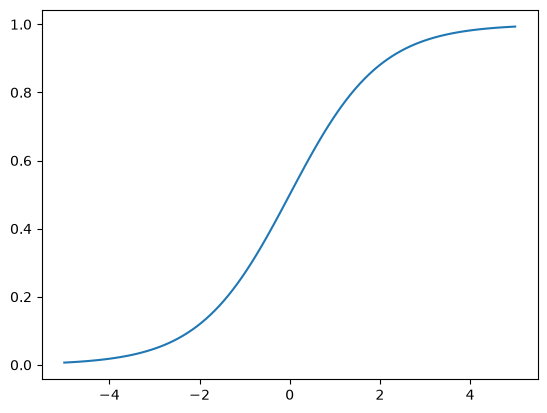

In [69]:
import numpy as np
import matplotlib.pyplot as plt



xs = np.linspace(-5, 5, 100) 
ys = [ 1/(1 + math.exp(-1*x) ) for x in xs ]
plt.figure(); plt.plot(xs, ys)
